<a href="https://colab.research.google.com/github/ruksana-ux/ML-models/blob/main/practice_class_dharna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Building model using Descision tree Classifer**

In [42]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning related imports
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Other utilities
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading dataset
df = pd.read_csv("titanic.csv")

In [3]:
# To check first five rows of the dataset
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# To check last five rows of the dataset
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [5]:
# To check the shape of the dataset ie; number of rows and columns
df.shape

(891, 12)

**Observations:**

* There are 891 rows and 12 columns.

In [6]:
# To check types of columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
# To check null values
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


**Observations:**

* Age: 177 null values

  Cabin: 687 null values
   
  Embarked: 2 null values

* Other columns has 0 null values

In [8]:
#To check duplication
print(df.duplicated().sum())

0


In [9]:
#To display the Statistical Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [10]:
df.describe(include = "object").T

,count,unique,top,freq
Name,891,891,"Dooley, Mr. Patrick",1
Sex,891,2,male,577
Ticket,891,681,347082,7
Cabin,204,147,G6,4
Embarked,889,3,S,644


In [11]:
df.describe(include = "object")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


In [12]:

# Define a list of columns to drop that are typically not required for analysis or modeling
columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'Embarked']

# Drop columns only if they exist in the DataFrame
# This makes the code robust to multiple executions or partial cleaning steps
df = df.drop([col for col in columns_to_drop if col in df.columns], axis=1)

print("Columns dropped successfully.")

# Display the first few rows and the new shape of the DataFrame to verify
display(df.head())
print(f"New DataFrame shape: {df.shape}")

Columns dropped successfully.


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500


New DataFrame shape: (891, 7)


* **The X variable is created using df.drop(["Survived"], axis = 1). This explicitly removes the 'Survived' column from the DataFrame, meaning X contains all the other columns (features) that will be used to predict 'Survived'.**

* **'y' holds the outcome we want to predict, and 'X' holds the information we'll use to make that prediction**.

In [13]:
# Since survived is the prediction/ ouput so we are keeping this in X
X = df.drop(["Survived"], axis = 1)

In [14]:
X

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,male,22.0,1,0,7.2500
1,1,female,38.0,1,0,71.2833
2,3,female,26.0,0,0,7.9250
3,1,female,35.0,1,0,53.1000
4,3,male,35.0,0,0,8.0500
...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000
887,1,female,19.0,0,0,30.0000
888,3,female,NaN,1,2,23.4500
889,1,male,26.0,0,0,30.0000


**To remove null values:**

**Imputation method**

* An imputation method is a technique used in data analysis to fill in missing values (null values) in a dataset.

In [15]:
# By using imputation method  we can fill null values
X['Age'].fillna(X['Age'].median(), inplace=True)

/tmp/ipykernel_688/2668834578.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['Age'].fillna(X['Age'].median(), inplace=True)


In [16]:
X

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,male,22.0,1,0,7.2500
1,1,female,38.0,1,0,71.2833
2,3,female,26.0,0,0,7.9250
3,1,female,35.0,1,0,53.1000
4,3,male,35.0,0,0,8.0500
...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000
887,1,female,19.0,0,0,30.0000
888,3,female,28.0,1,2,23.4500
889,1,male,26.0,0,0,30.0000


Now, let's verify that the missing values in 'Age' have been handled.

In [17]:
X.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0


In [18]:
X = pd.get_dummies(X, columns=['Sex'], drop_first=True)
print('DataFrame after one-hot encoding for Sex:')
display(X.head())

DataFrame after one-hot encoding for Sex:


,Pclass,Age,SibSp,Parch,Fare,Sex_male
0,3,22.0,1,0,7.2500,True
1,1,38.0,1,0,71.2833,False
2,3,26.0,0,0,7.9250,False
3,1,35.0,1,0,53.1000,False
4,3,35.0,0,0,8.0500,True


**To check null values after update**

Let's verify the updated data types and ensure no more categorical columns need encoding.

In [19]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Age       891 non-null    float64
 2   SibSp     891 non-null    int64  
 3   Parch     891 non-null    int64  
 4   Fare      891 non-null    float64
 5   Sex_male  891 non-null    bool   
dtypes: bool(1), float64(2), int64(3)
memory usage: 35.8 KB


# **Splitting the dataset into x-train and x-test and y-train and y-test**

The data has been successfully split into training and testing sets. Now, we can proceed with training a machine learning model. Which model would you like to use?

In [20]:
# y contains only the 'Survived' column,
# which is typically what we want to predict in a machine learning model.

y = df["Survived"] # keeping susvived in y where values are in 0 and 1

In [21]:
y

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [22]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [23]:
X_train.shape

(712, 6)

In [24]:
X_test.shape

(179, 6)

In [25]:
y_train.shape

(712,)

In [26]:
y_test.shape

(179,)

* **X= X.values: This step is often necessary because many machine learning libraries and algorithms, especially those built on scientific computing foundations like scikit-learn, expect their input data to be in the form of NumPy arrays**

In [45]:
# To converts the pandas DataFrame X into a NumPy array.
# NumPy arrays are more efficient for numerical computations that machine learning models perform.
# This step is commented out as X_train and X_test are already created as DataFrames before this, and this X is not used further.
# X=X.values

In [29]:
X

array([[3, 22.0, 1, 0, 7.25, True],
       [1, 38.0, 1, 0, 71.2833, False],
       [3, 26.0, 0, 0, 7.925, False],
       ...,
       [3, 28.0, 1, 2, 23.45, False],
       [1, 26.0, 0, 0, 30.0, True],
       [3, 32.0, 0, 0, 7.75, True]], dtype=object)

# Imputation method
**One hot encoder:**

* One-hot encoding is a process of converting categorical variables into a numerical format that can be easily used by machine learning algorithms.

* **handling Nominal Data:** It is particularly useful for nominal categorical variables, where there is no intrinsic order between the categories (e.g., 'red', 'blue', 'green').

In [32]:
from sklearn.preprocessing import OneHotEncoder

**ColumnTransformer**

* it is a powerful tool used in scikit-learn for applying different transformations to different columns of your dataset.

* It allows you to build more complex preprocessing pipelines, especially when your dataset contains a mix of numerical and categorical features that require different kinds of preprocessing

In [47]:
model=DecisionTreeClassifier(criterion='entropy')

In [48]:
model.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy')

* **model:** This refers to trained machine learning model, which in this case is a DecisionTreeClassifier we previously fitted using model.fit(X_train, y_train).

* **.predict():** This is a method available on trained scikit-learn models (and many other ML libraries) that generates predictions on new, unseen data.

* **X_test: **This is our testing dataset, containing the features of the data points that the model has not seen during its training phase.

* It's used to evaluate how well the model generalizes to new data.

In [49]:
y_pred = model.predict(X_test)

In [50]:
y_pred

array([0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1])

In [51]:
metrics.accuracy_score(y_test,y_pred)

0.7597765363128491

# **Project on random forest using lungs cancer dataset**

**Importing libraries**

In [44]:
# All necessary imports have been consolidated into the initial import cell.
# Libraries to help with reading and manipulating data
# import numpy as np
# import pandas as pd

# importing libraries for visualization
# import matplotlib.pyplot as plt
# import seaborn as sns

# Libraries to split data
# from sklearn.model_selection import train_test_split

# Libraries to import classifiers
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import BaggingClassifier
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import GridSearchCV

# from sklearn import metrics
# from sklearn.metrics import confusion_matrix, classification_report
# from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score, roc_auc_score
# import scipy.stats as stats

# import warnings
# warnings.filterwarnings('ignore')

# **Loading Dataset**

In [ ]:
# loading the dataset
df=pd.read_csv('lung_cancer.csv')

# **DATA OVERVIEW**

In [ ]:
# viewing the first 5 rows of the data
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,F,61,2,2,2,1,1,2,2,1,2,1,2,2,2,YES
1,M,69,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
2,F,53,2,2,2,1,2,1,1,2,2,1,2,2,2,YES
3,M,55,1,2,1,1,1,2,1,2,2,2,2,1,1,NO
4,F,57,2,2,1,1,1,1,1,1,1,1,2,1,1,NO


**To check missing values**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3309 entries, 0 to 3308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 3309 non-null   object
 1   AGE                    3309 non-null   int64 
 2   SMOKING                3309 non-null   int64 
 3   YELLOW_FINGERS         3309 non-null   int64 
 4   ANXIETY                3309 non-null   int64 
 5   PEER_PRESSURE          3309 non-null   int64 
 6   CHRONIC DISEASE        3309 non-null   int64 
 7   FATIGUE                3309 non-null   int64 
 8   ALLERGY                3309 non-null   int64 
 9   WHEEZING               3309 non-null   int64 
 10  ALCOHOL CONSUMING      3309 non-null   int64 
 11  COUGHING               3309 non-null   int64 
 12  SHORTNESS OF BREATH    3309 non-null   int64 
 13  SWALLOWING DIFFICULTY  3309 non-null   int64 
 14  CHEST PAIN             3309 non-null   int64 
 15  LUNG_CANCER          

**To check last 5 rows of the dataset**

In [ ]:
df.tail()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
3304,F,64,1,2,2,2,1,1,2,2,1,2,1,2,1,YES
3305,F,21,2,1,1,1,2,2,2,1,1,1,2,1,1,NO
3306,M,60,2,1,1,1,1,2,2,2,2,2,2,1,2,YES
3307,M,72,2,2,2,2,2,1,2,2,2,2,1,2,2,YES
3308,M,65,1,2,2,1,1,2,1,2,2,2,2,2,2,YES


**To check number of columns and rows**

In [ ]:
df.shape

(3309, 16)

**To check missing values**

In [ ]:
# checking for missing values
df.isnull().sum()

,0
GENDER,0
AGE,0
SMOKING,0
YELLOW_FINGERS,0
ANXIETY,0
PEER_PRESSURE,0
CHRONIC DISEASE,0
FATIGUE,0
ALLERGY,0
WHEEZING,0


**To check the statistical summary of the data**

In [ ]:
# getting some statistical measures about the data
df.describe()

,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
count,3309.000000,3309.000000,3309.000000,3309.000000,3309.000000,3309.000000,3309.000000,3309.000000,3309.000000,3309.000000,3309.000000,3309.000000,3309.000000,3309.000000
mean,55.869749,1.497733,1.519190,1.494409,1.499244,1.509217,1.506800,1.511333,1.502871,1.497431,1.517075,1.502267,1.487761,1.504080
std,14.407765,0.500070,0.499707,0.500044,0.500075,0.499991,0.500029,0.499947,0.500067,0.500069,0.499784,0.500070,0.499926,0.500059
min,21.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,44.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,56.000000,1.000000,2.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2.000000,1.000000,2.000000
75%,68.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,87.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [ ]:
# getting some statistical measures about the data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
AGE,3309.0,55.869749,14.407765,21.0,44.0,56.0,68.0,87.0
SMOKING,3309.0,1.497733,0.500070,1.0,1.0,1.0,2.0,2.0
YELLOW_FINGERS,3309.0,1.519190,0.499707,1.0,1.0,2.0,2.0,2.0
ANXIETY,3309.0,1.494409,0.500044,1.0,1.0,1.0,2.0,2.0
PEER_PRESSURE,3309.0,1.499244,0.500075,1.0,1.0,1.0,2.0,2.0
CHRONIC DISEASE,3309.0,1.509217,0.499991,1.0,1.0,2.0,2.0,2.0
FATIGUE,3309.0,1.506800,0.500029,1.0,1.0,2.0,2.0,2.0
ALLERGY,3309.0,1.511333,0.499947,1.0,1.0,2.0,2.0,2.0
WHEEZING,3309.0,1.502871,0.500067,1.0,1.0,2.0,2.0,2.0
ALCOHOL CONSUMING,3309.0,1.497431,0.500069,1.0,1.0,1.0,2.0,2.0


In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
GENDER,3309,2,M,1676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AGE,3309.0,NaN,NaN,NaN,55.869749,14.407765,21.0,44.0,56.0,68.0,87.0
SMOKING,3309.0,NaN,NaN,NaN,1.497733,0.50007,1.0,1.0,1.0,2.0,2.0
YELLOW_FINGERS,3309.0,NaN,NaN,NaN,1.51919,0.499707,1.0,1.0,2.0,2.0,2.0
ANXIETY,3309.0,NaN,NaN,NaN,1.494409,0.500044,1.0,1.0,1.0,2.0,2.0
PEER_PRESSURE,3309.0,NaN,NaN,NaN,1.499244,0.500075,1.0,1.0,1.0,2.0,2.0
CHRONIC DISEASE,3309.0,NaN,NaN,NaN,1.509217,0.499991,1.0,1.0,2.0,2.0,2.0
FATIGUE,3309.0,NaN,NaN,NaN,1.5068,0.500029,1.0,1.0,2.0,2.0,2.0
ALLERGY,3309.0,NaN,NaN,NaN,1.511333,0.499947,1.0,1.0,2.0,2.0,2.0
WHEEZING,3309.0,NaN,NaN,NaN,1.502871,0.500067,1.0,1.0,2.0,2.0,2.0


**To check null values**

In [ ]:
# checking for null values
df.duplicated().sum()

np.int64(35)

**To check unique values**

In [ ]:
# checking the number of unique values in each column
df.nunique()

,0
GENDER,2
AGE,54
SMOKING,2
YELLOW_FINGERS,2
ANXIETY,2
PEER_PRESSURE,2
CHRONIC DISEASE,2
FATIGUE,2
ALLERGY,2
WHEEZING,2


In [46]:
# The 'LUNG_CANCER' column, which is the target variable, should not be dropped from the main DataFrame at this stage.
# It will be separated into a target variable (y_lung_cancer) later.
# df.drop(labels='LUNG_CANCER', axis=1, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3309 entries, 0 to 3308
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 3309 non-null   object
 1   AGE                    3309 non-null   int64 
 2   SMOKING                3309 non-null   int64 
 3   YELLOW_FINGERS         3309 non-null   int64 
 4   ANXIETY                3309 non-null   int64 
 5   PEER_PRESSURE          3309 non-null   int64 
 6   CHRONIC DISEASE        3309 non-null   int64 
 7   FATIGUE                3309 non-null   int64 
 8   ALLERGY                3309 non-null   int64 
 9   WHEEZING               3309 non-null   int64 
 10  ALCOHOL CONSUMING      3309 non-null   int64 
 11  COUGHING               3309 non-null   int64 
 12  SHORTNESS OF BREATH    3309 non-null   int64 
 13  SWALLOWING DIFFICULTY  3309 non-null   int64 
 14  CHEST PAIN             3309 non-null   int64 
dtypes: int64(14), object(

In [ ]:
# fixing column names
df.columns = [c.replace(" ", "_") for c in df.columns]

**Fixing the data types**

**Converting object type to categorical data type**

In [ ]:
cols = df.select_dtypes(['object'])
cols.columns

Index(['GENDER'], dtype='object')

In [ ]:
for i in cols.columns:
    df[i] = df[i].astype('category')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3309 entries, 0 to 3308
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   GENDER                 3309 non-null   category
 1   AGE                    3309 non-null   int64   
 2   SMOKING                3309 non-null   int64   
 3   YELLOW_FINGERS         3309 non-null   int64   
 4   ANXIETY                3309 non-null   int64   
 5   PEER_PRESSURE          3309 non-null   int64   
 6   CHRONIC_DISEASE        3309 non-null   int64   
 7   FATIGUE_               3309 non-null   int64   
 8   ALLERGY_               3309 non-null   int64   
 9   WHEEZING               3309 non-null   int64   
 10  ALCOHOL_CONSUMING      3309 non-null   int64   
 11  COUGHING               3309 non-null   int64   
 12  SHORTNESS_OF_BREATH    3309 non-null   int64   
 13  SWALLOWING_DIFFICULTY  3309 non-null   int64   
 14  CHEST_PAIN             3309 non-null   i

* This is used for exploratory data analysis (EDA), specifically to visualize the distribution of numerical features in your DataFrame.

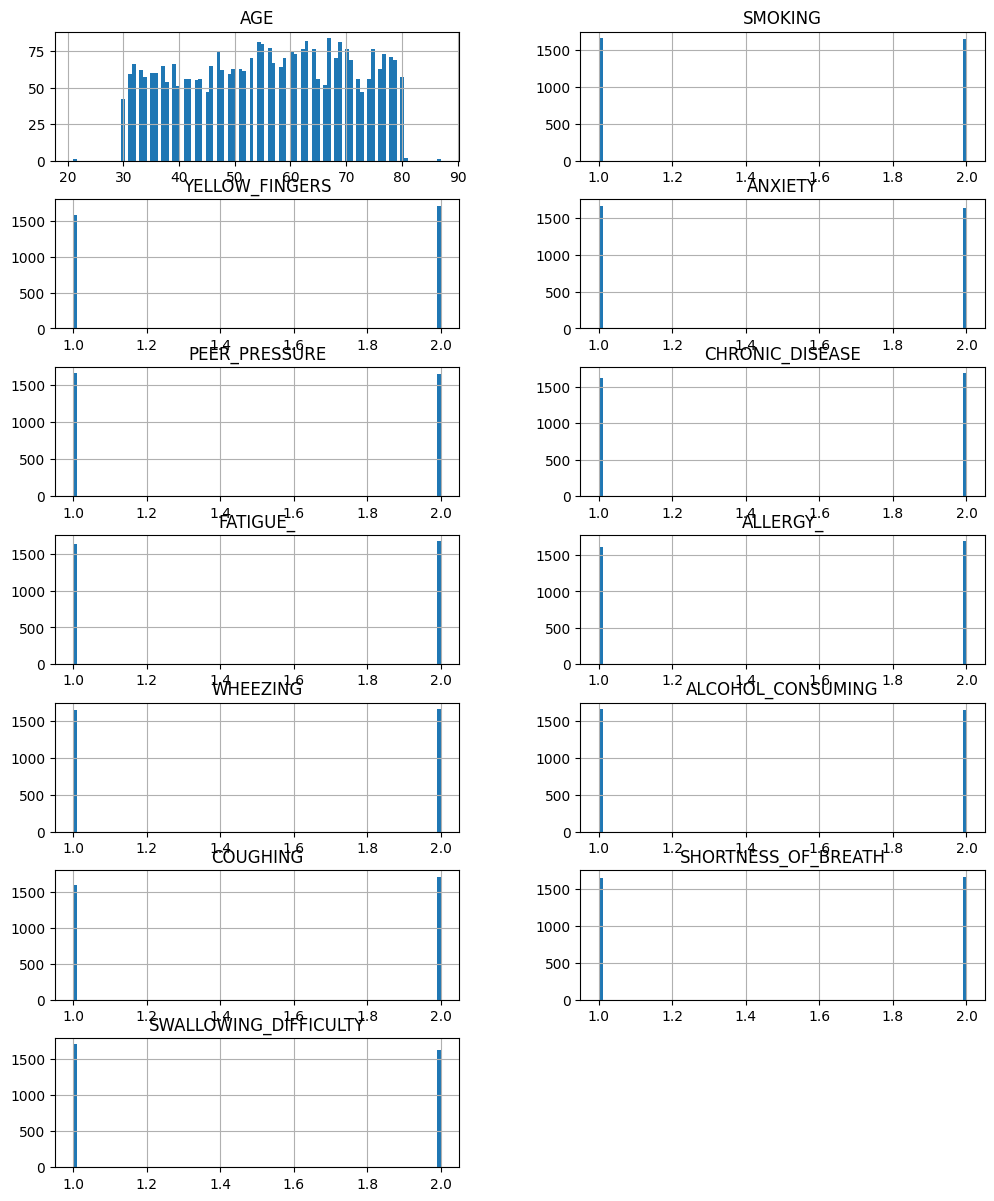

In [ ]:
columns=list(df)[0:-1]
df[columns].hist(stacked=False,bins=100,figsize=(12,30),layout=(14,2));

**looking at the unique values of all the categories**

In [ ]:
# df.select_dtypes(['category']) is used to filter DataFrame df and
# select only those columns that have a category data type.
# cols_cat is a variable

cols_cat= df.select_dtypes(['category'])

In [ ]:
for i in cols_cat.columns:
    print('Unique values in',i, 'are :')
    print(cols_cat[i].value_counts())
    print('*'*50)

Unique values in GENDER are :
GENDER
M    1676
F    1633
Name: count, dtype: int64
**************************************************


# **Exploratory Data Analysis**


# **Univariate Analysis**

In [ ]:
def histogram_boxplot(data, feature, figsize=(8, 10), kde=False, bins=None):

    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

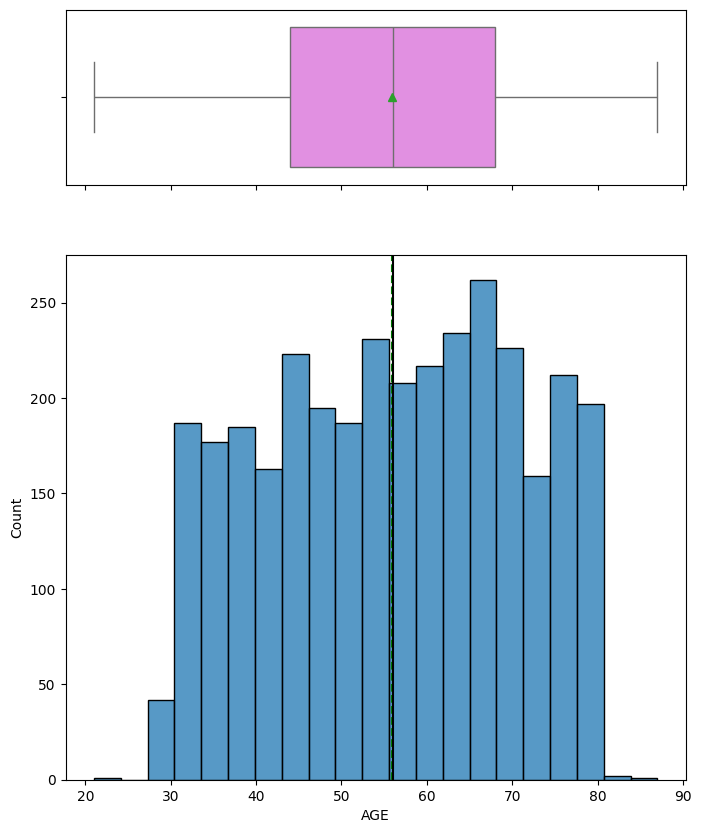

In [ ]:
histogram_boxplot(df,'AGE')

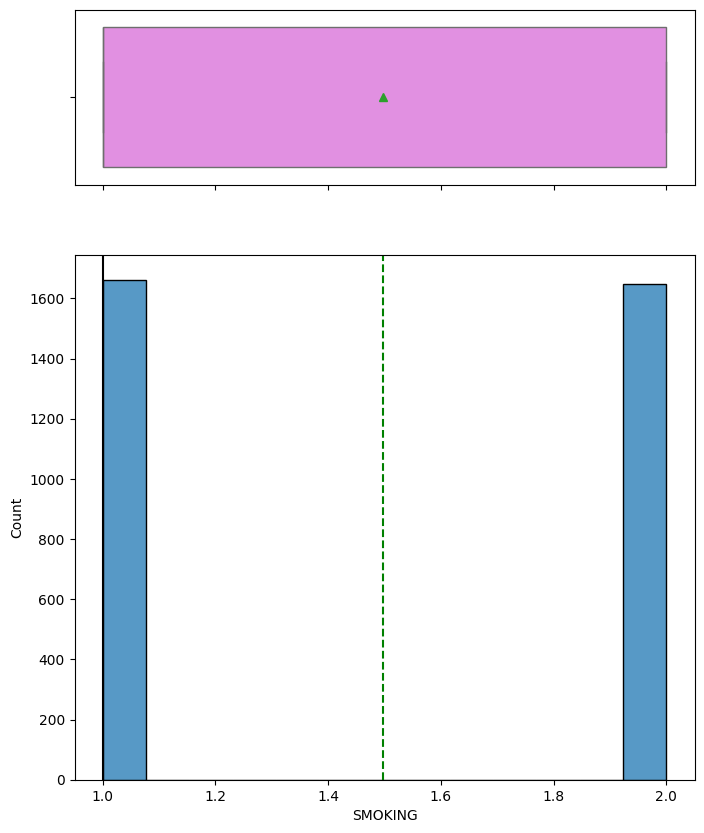

In [ ]:
histogram_boxplot(df,'SMOKING')

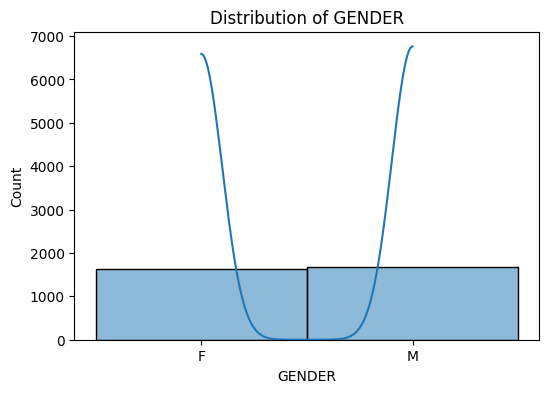

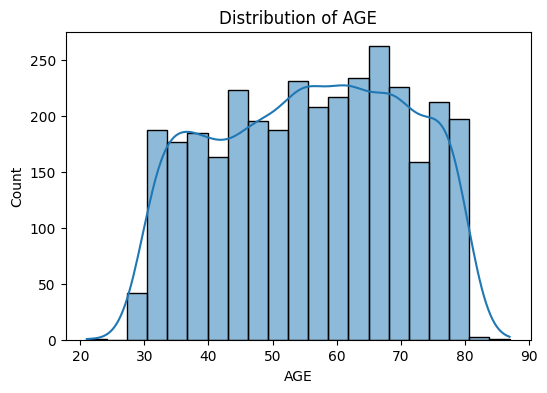

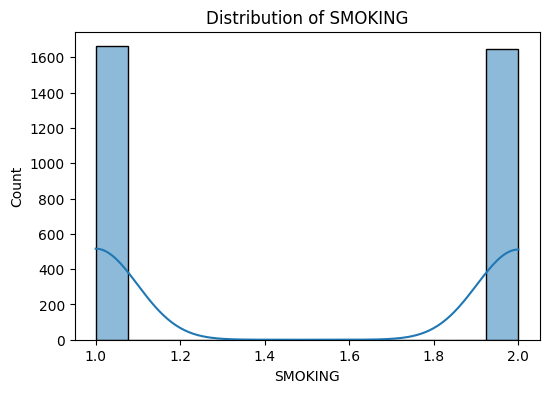

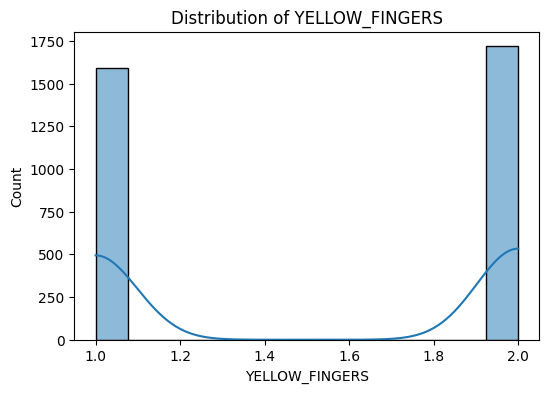

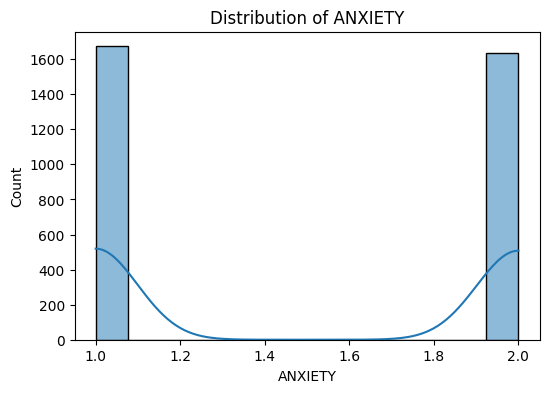

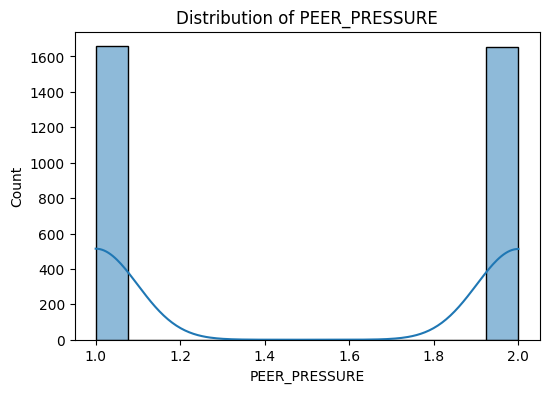

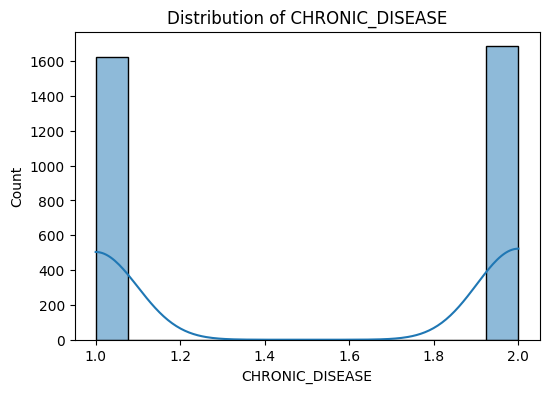

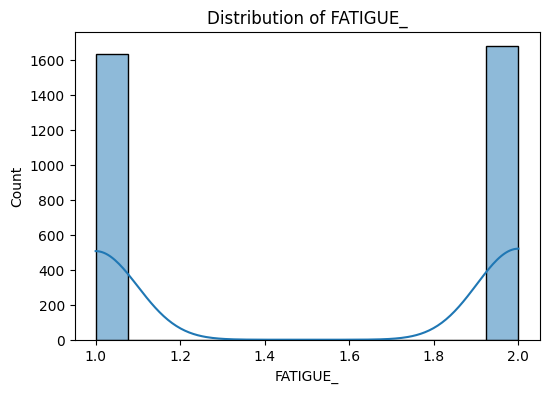

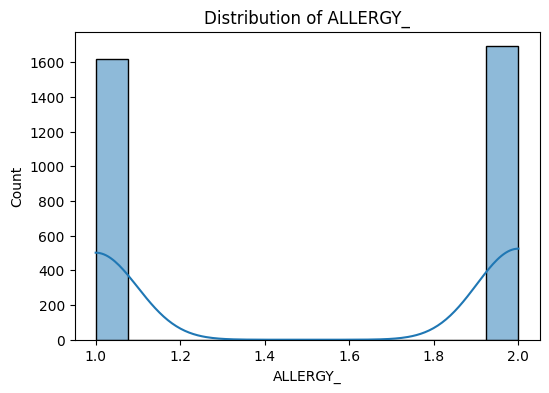

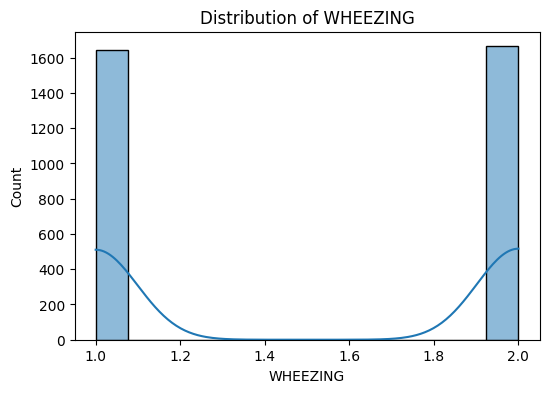

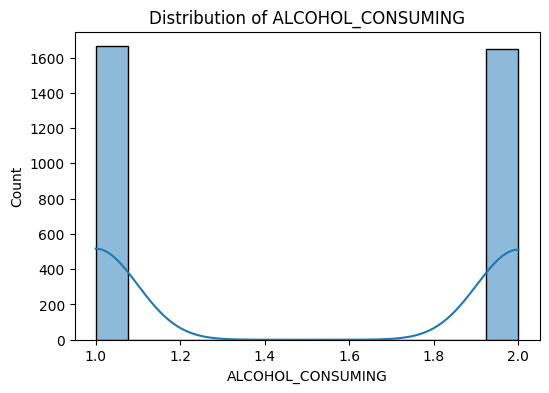

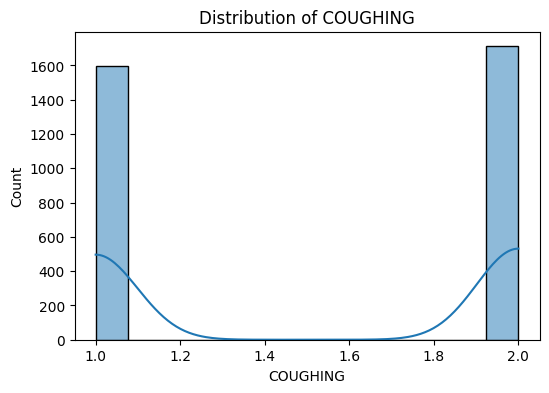

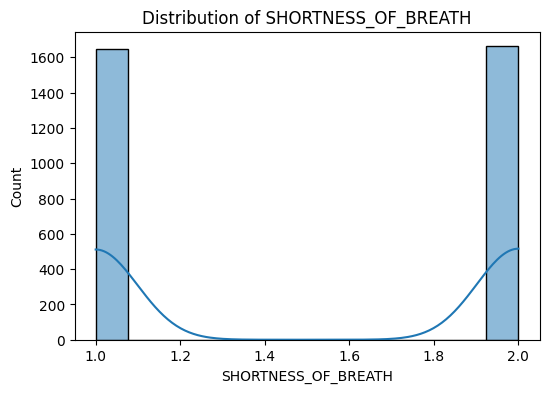

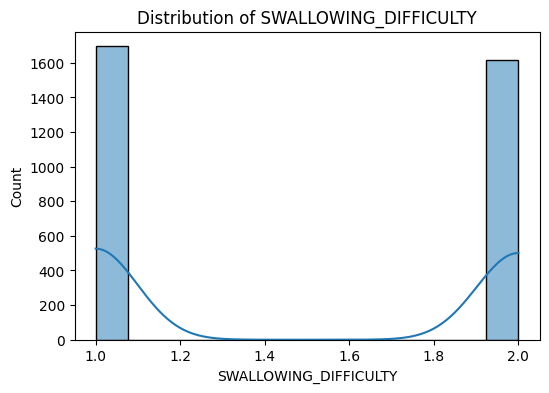

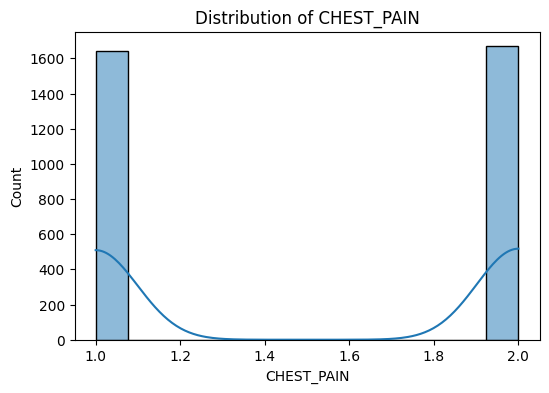

In [ ]:
# Distribution plots for important variables
import matplotlib.pyplot as plt
import seaborn as sns

# Getting all column names
important_vars = df.columns.tolist()

# we can manually select specific columns by name:
# important_vars = ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
#        'UnitPrice', 'CustomerID', 'Country'] # example

for var in important_vars:
    plt.figure(figsize=(6, 4))
    sns.histplot(x=var, data=df, kde=True)  # kde adds a density curve
    plt.title(f'Distribution of {var}')
    plt.show()

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

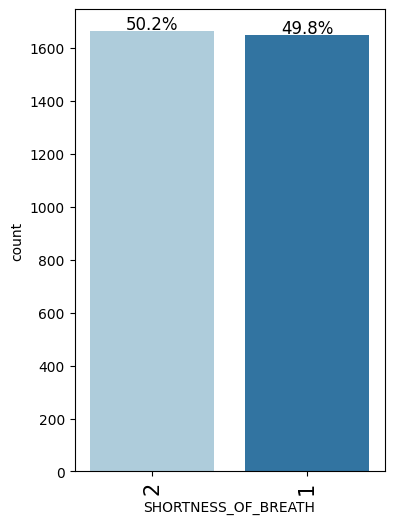

In [ ]:
labeled_barplot(df, "SHORTNESS_OF_BREATH", perc=True)

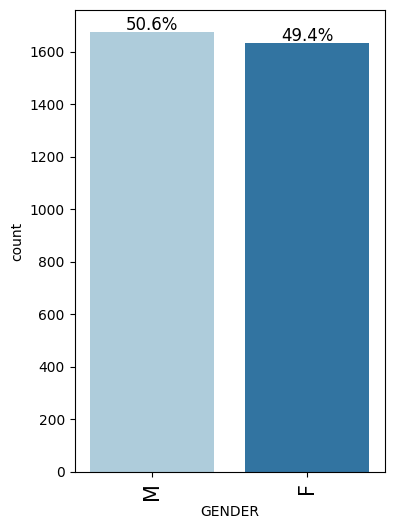

In [ ]:
labeled_barplot(df, "GENDER", perc=True)

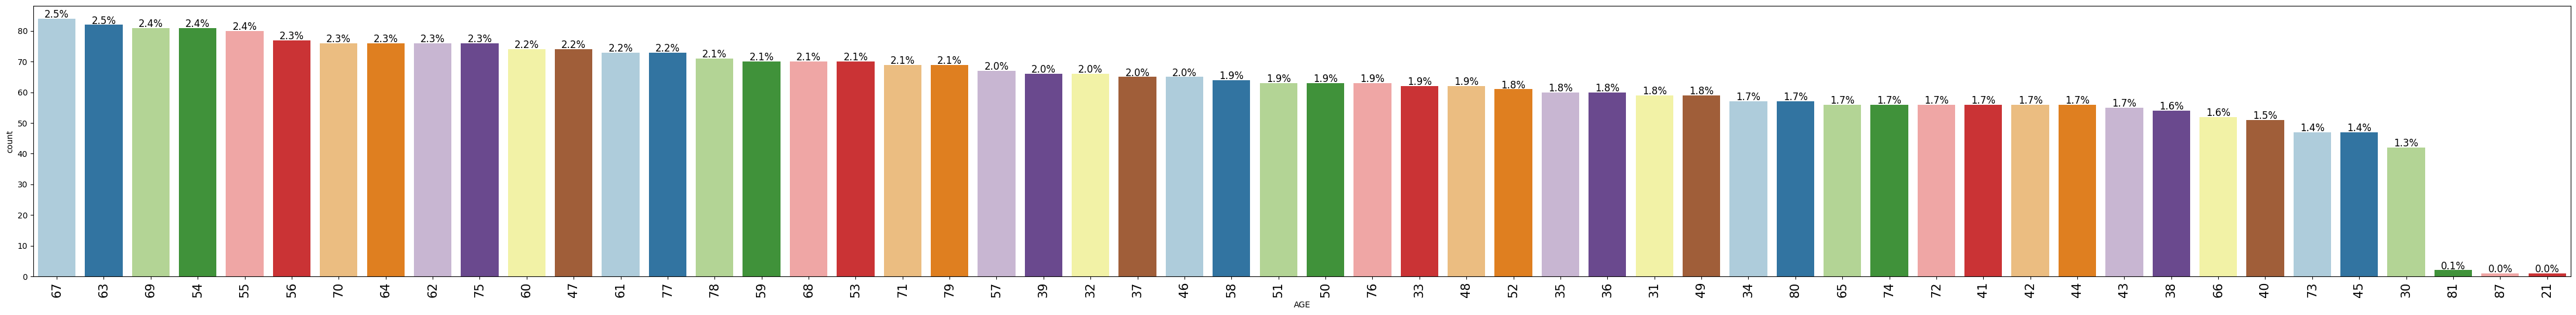

In [ ]:
labeled_barplot(df, "AGE", perc=True)

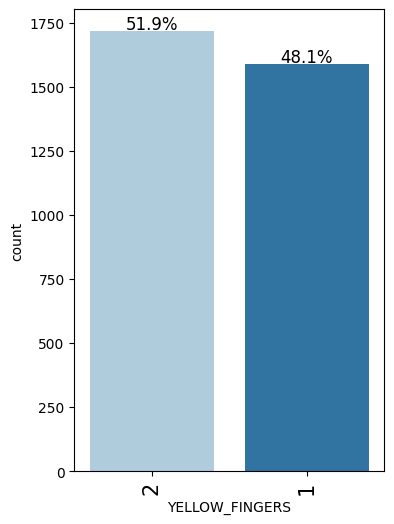

In [ ]:
labeled_barplot(df, "YELLOW_FINGERS", perc=True)

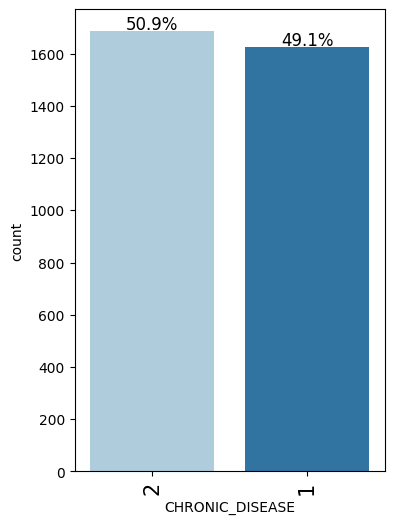

In [ ]:
labeled_barplot(df, "CHRONIC_DISEASE", perc=True)

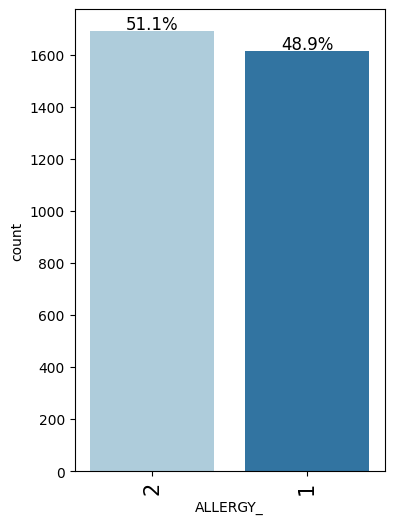

In [ ]:
labeled_barplot(df, "ALLERGY_", perc=True)

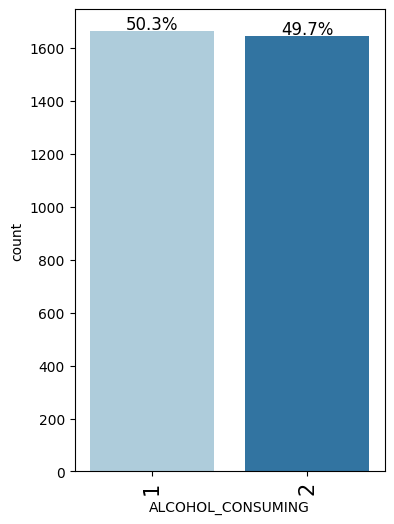

In [ ]:
labeled_barplot(df, "ALCOHOL_CONSUMING", perc=True)

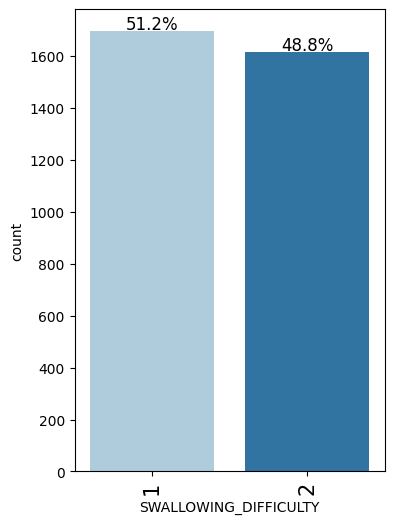

In [ ]:
labeled_barplot(df, "SWALLOWING_DIFFICULTY", perc=True)

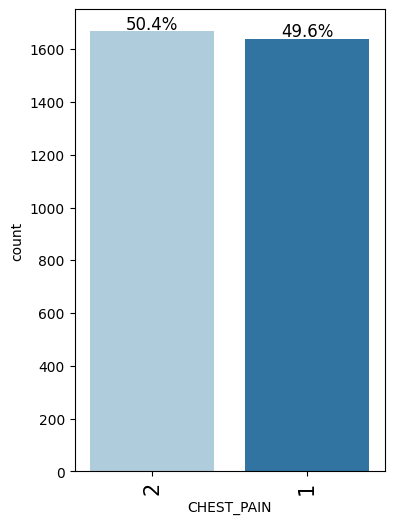

In [ ]:
labeled_barplot(df, "CHEST_PAIN", perc=True)

# **BIVARIATE ANALYSIS**

* A correlation check (or correlation analysis) is a statistical method used to evaluate the strength and direction of a linear relationship between two or more quantitative variables.

**Positive Correlation**: As one variable increases, the other tends to increase (e.g., more study time might correlate with higher grades).

**Negative Correlation:** As one variable increases, the other tends to decrease (e.g., more hours of exercise might correlate with lower body fat).

**No Correlation:** There's no consistent linear relationship between the variables.

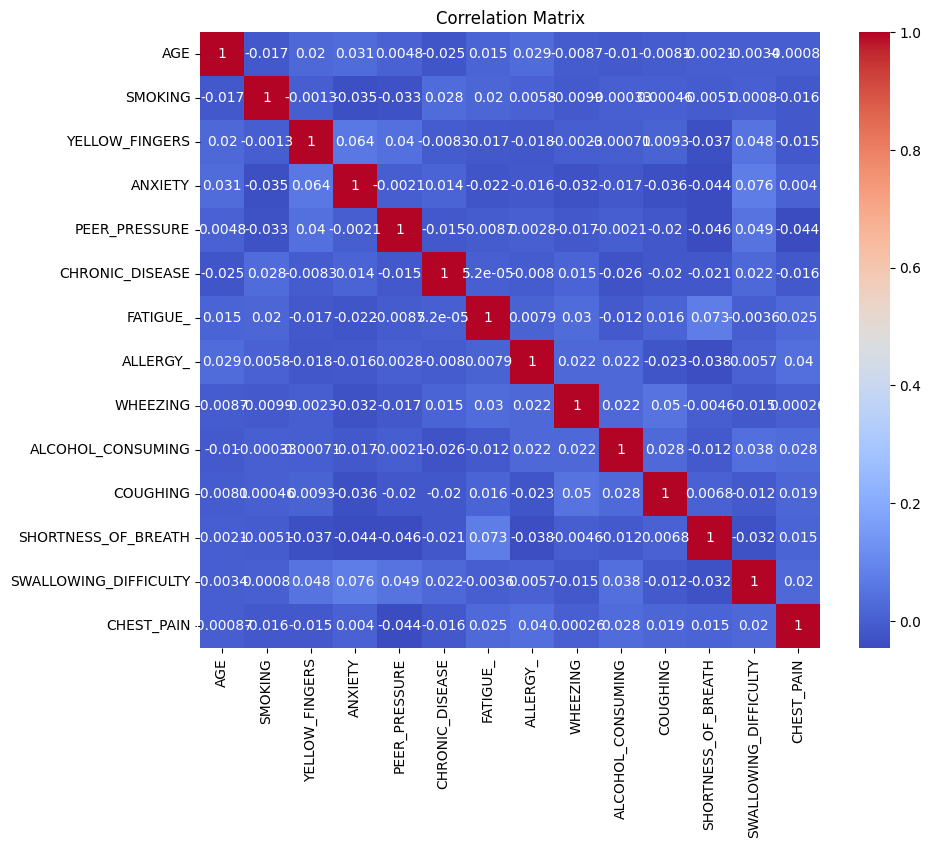

In [ ]:
# Correlation matrix
numerical_data = df.select_dtypes(include=np.number)  # Select only numerical columns
correlation_matrix = numerical_data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

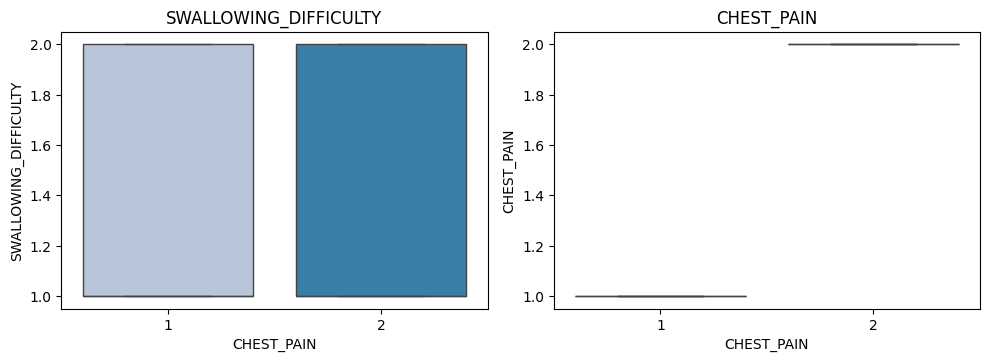

In [ ]:
cols = df[['SWALLOWING_DIFFICULTY','CHEST_PAIN']].columns.tolist()
plt.figure(figsize=(10,10))

for i, variable in enumerate(cols):
                     plt.subplot(3,2,i+1)
                     sns.boxplot(x=df["CHEST_PAIN"],y=df[variable],palette="PuBu")
                     plt.tight_layout()
                     plt.title(variable)
plt.show()

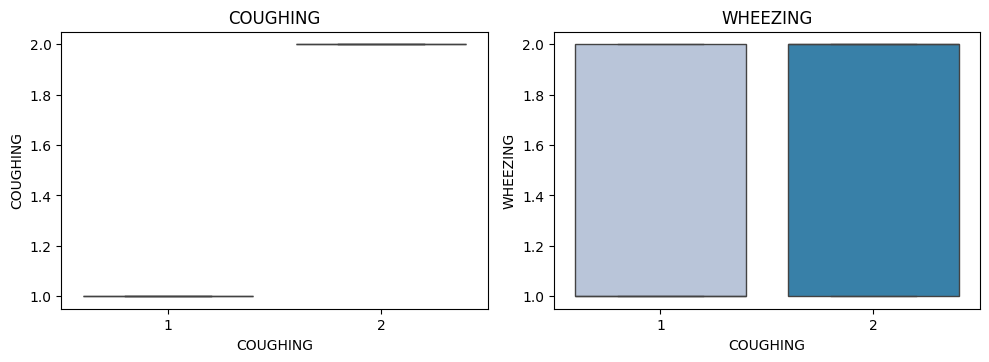

In [ ]:
cols = df[['COUGHING','WHEEZING']].columns.tolist()
plt.figure(figsize=(10,10))

for i, variable in enumerate(cols):
                     plt.subplot(3,2,i+1)
                     sns.boxplot(x=df["COUGHING"],y=df[variable],palette="PuBu")
                     plt.tight_layout()
                     plt.title(variable)
plt.show()

In [ ]:
# function to plot distributions wrt target
def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(10, 8))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
         x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

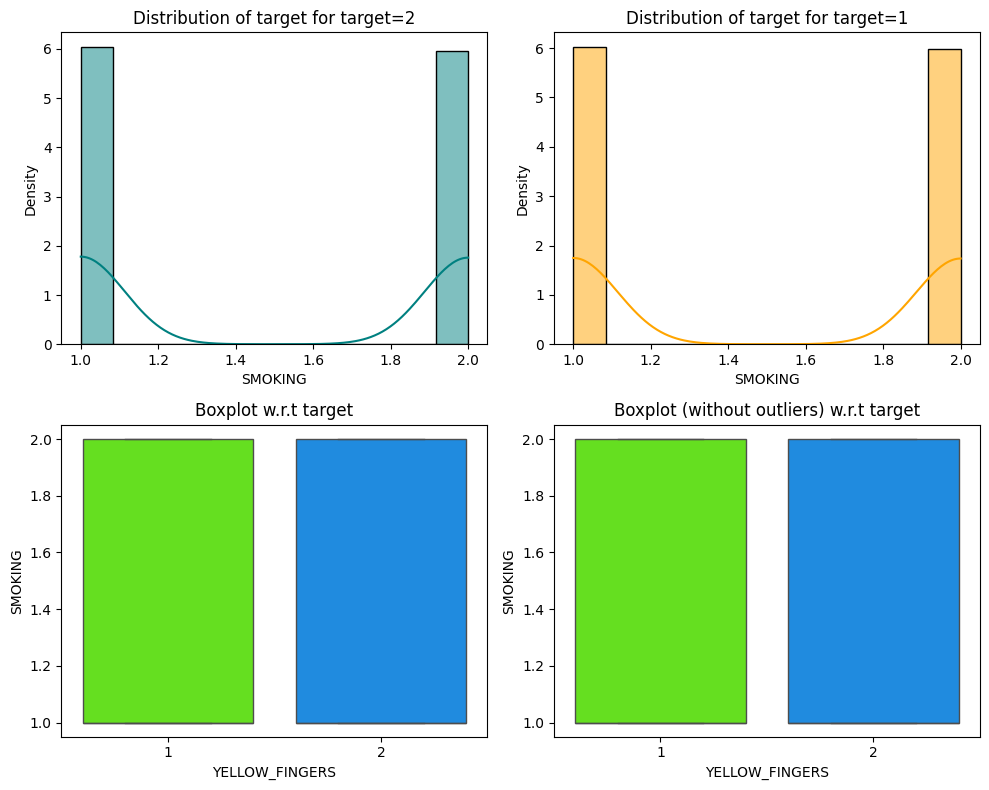

In [ ]:
distribution_plot_wrt_target(df, "SMOKING", "YELLOW_FINGERS")

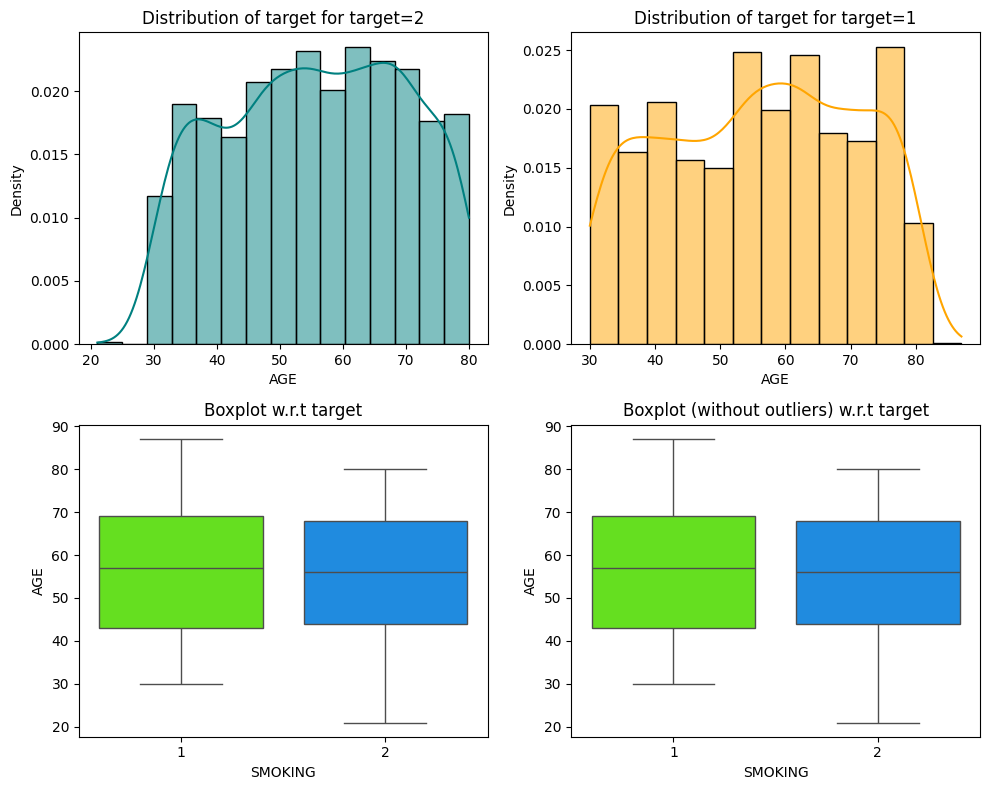

In [ ]:
distribution_plot_wrt_target(df, "AGE", "SMOKING")

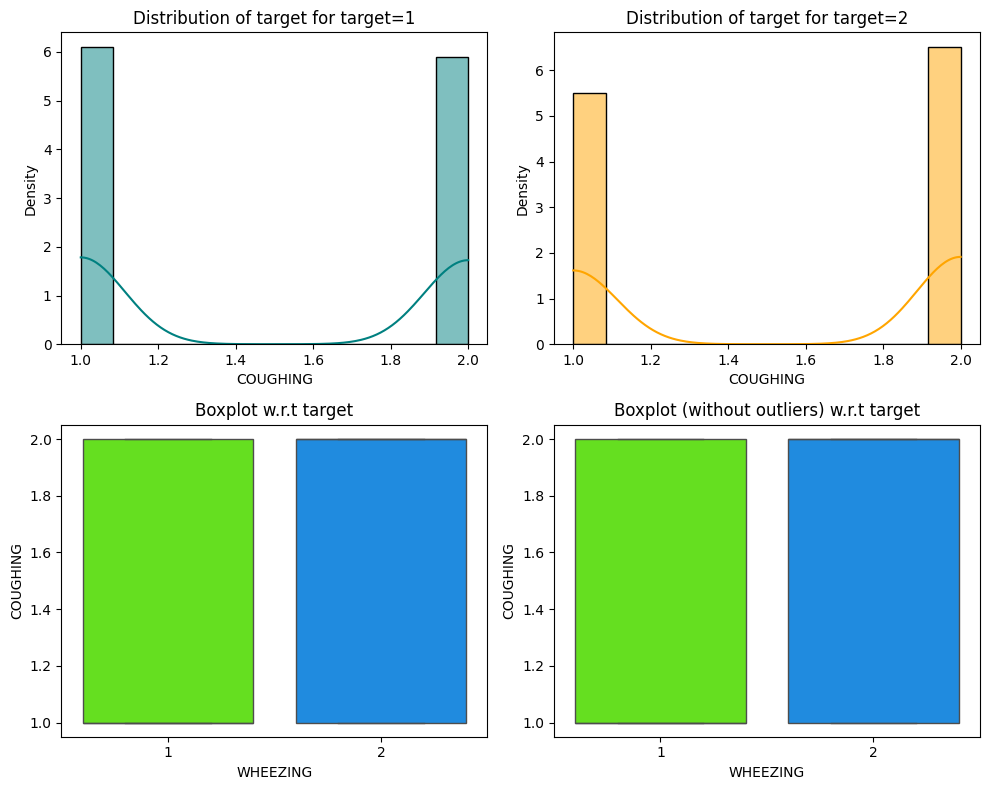

In [ ]:
distribution_plot_wrt_target(df, "COUGHING", "WHEEZING")

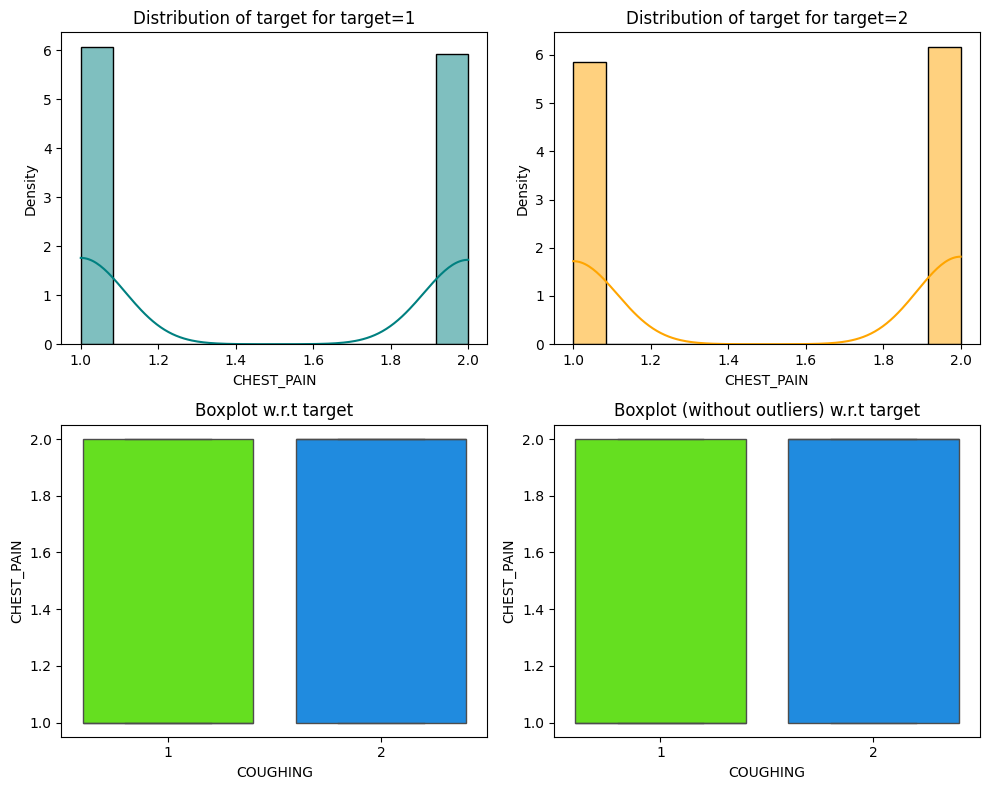

In [ ]:
distribution_plot_wrt_target(df, "CHEST_PAIN", "COUGHING")

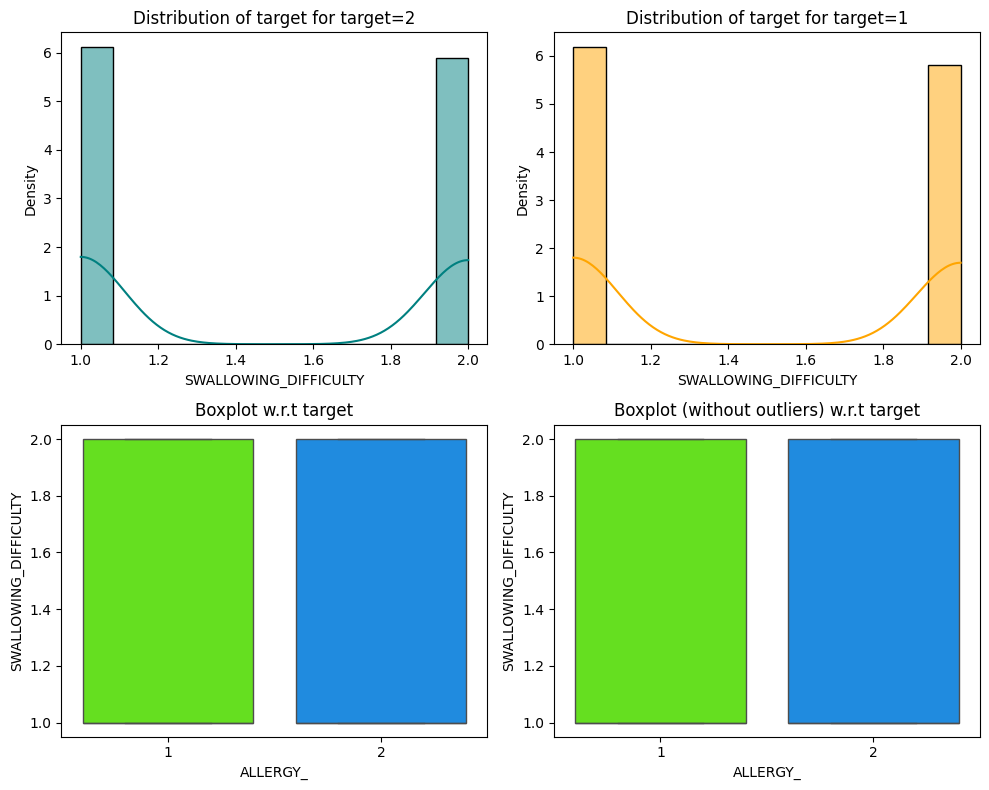

In [ ]:
distribution_plot_wrt_target(df, "SWALLOWING_DIFFICULTY", "ALLERGY_")

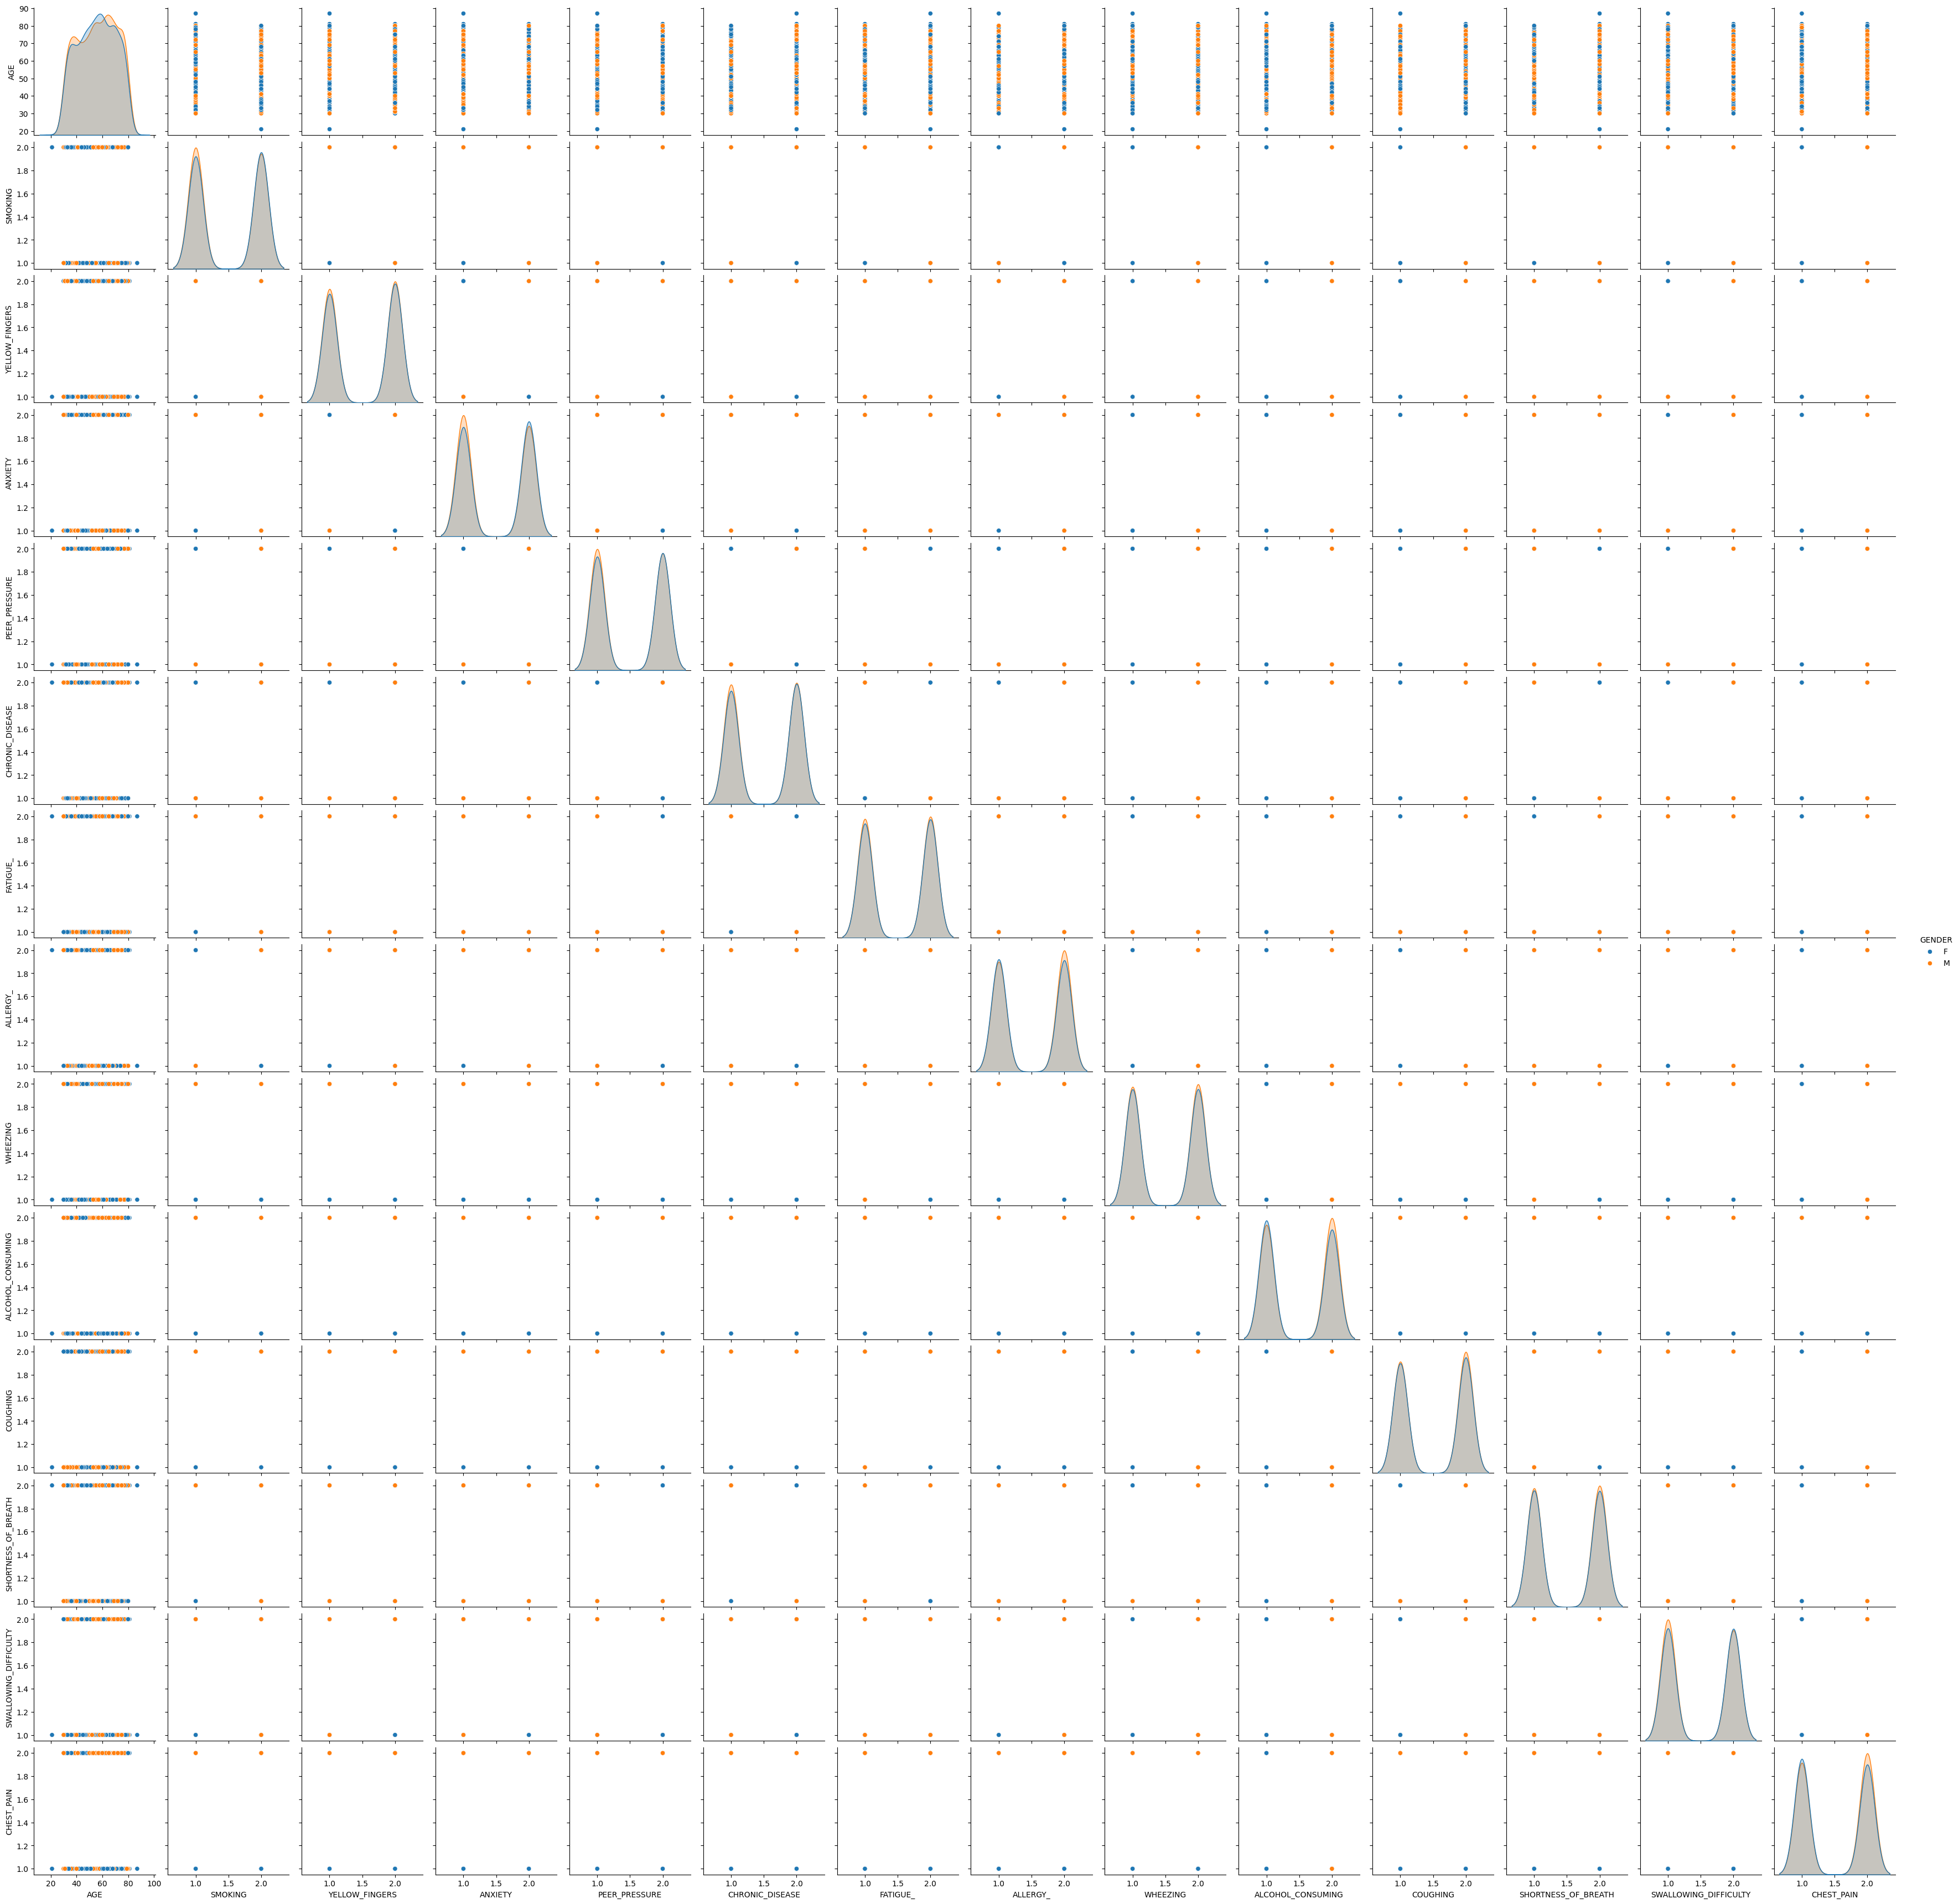

In [ ]:
sns.pairplot(df, hue="GENDER", diag_kind="kde")
plt.show()

In [ ]:
sns.boxplot(x=df['SMOKING'],y=df[''])
plt.show()

# **DATA PREPROCESSING**